In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model
from itertools import combinations
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [24]:
df = pd.read_csv("Training Set_16.csv")
df

,Ligand Name,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
0,5-IMes,1.00,2.00,-0.484674,-1804.2453,-1804.7901,0.544791,-1806.2855,2.05604,1.98859,...,-0.25111,-0.23408,-0.24280,-0.25121,31.60,61.84,221.94,251.94,1.73952,-0.23268
1,5-IMes(Me),1.00,1.80,-0.411002,-1882.8182,-1883.4157,0.597507,-1884.9254,2.05896,1.98482,...,-0.24786,-0.23158,-0.24162,-0.24870,30.16,63.78,219.11,247.82,1.73538,-0.22952
2,5-IPr,1.80,1.00,0.411002,-2039.8947,-2040.6098,0.715108,-2042.1522,2.06852,1.98918,...,-0.25299,-0.23952,-0.25146,-0.25613,29.49,62.57,198.12,226.10,1.73784,-0.23608
3,"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-2884.9649,-2885.9336,0.968654,-2887.6474,2.07858,1.97721,...,-0.26154,-0.25844,-0.26562,-0.25147,24.49,66.27,171.17,206.26,1.73388,-0.24368
4,5-IPr**,6.14,1.00,1.268993,-4908.3608,-4910.3959,2.035083,-4912.5098,2.07065,1.98778,...,-0.26097,-0.25692,-0.25009,-0.25588,22.39,62.91,155.83,192.42,1.74199,-0.24136
5,5-IPr*,6.50,1.00,1.308833,-3651.4681,-3652.6320,1.163937,-3654.5018,2.07089,1.98778,...,-0.26207,-0.26152,-0.26535,-0.24701,23.72,62.93,160.72,195.84,1.73997,-0.24433
6,5-IPent,4.00,1.00,0.969348,-2354.1126,-2355.0496,0.936960,-2356.6538,2.07486,1.98351,...,-0.25121,-0.23657,-0.24991,-0.25489,28.42,68.42,179.95,206.17,1.72162,-0.23286
7,5-Np#,1.40,1.00,0.235274,-4882.1648,-4883.7215,1.556706,-4885.8399,2.05552,1.98500,...,-0.26148,-0.24280,-0.26055,-0.25152,22.91,68.51,164.03,200.73,1.72031,-0.23891
8,5-IEt,1.00,1.33,-0.199408,-1961.3491,-1962.0085,0.659387,-1963.5345,2.06528,1.98437,...,-0.25157,-0.23429,-0.24372,-0.25233,30.68,63.01,204.90,235.47,1.73696,-0.23269
9,6-SIPr,3.80,1.00,0.933482,-2080.3582,-2081.1251,0.766884,-2082.6745,2.12257,1.98664,...,-0.25080,-0.23792,-0.24795,-0.25398,19.16,65.66,170.88,210.19,1.73804,-0.23331


In [25]:
parm = ['ΔG_int', 'E(RwB97XD)_int', 'ΔH(RwB97XD)_int',
       'SP_E(RwB97XD)_int', 'BL(C28-Pd)', 'BL(C12-Pd)', 'BA (C28-Pd-C12)',
       'BA(N-C-N)', '%Vbur(3.5Å)', '%Vbur(4.0Å)', '%Vbur(3.0Å)', 'NPA (C28)',
       'NPA (C12)', 'NPA (Pd)', 'NPA (Cipso)', 'NPA (O)', 'MC(C28)', 'MC(C12)',
       'MC(Pd)', 'SP_MC(C28)', 'SP_MC(C12)', 'SP_MC(Pd)', 'MM_int', 'P(α)_int',
       'DM_int', 'DM(SP)_int', 'HC(Cv)_int', 'E(S)_int', 'Occ.(dxy)_Pd ',
       'Occ.(dxz)_Pd ', 'Occ.(dyz)_Pd', 'Occ.(dx2y2)_Pd', 'Occ.dz2)_Pd',
       'E_dxy_Pd', 'E_dxz_Pd', 'E_dyz_Pd', 'E_dx2y2_Pd', 'E_dz2_Pd',
       'E_Pd(LP)-C28(LP*)', 'E_Pd(LP)-C12(LP*)', 'E_C28(LP)-Pd(LP*)',
       'E_C12(LP)-Pd(LP*)', 'Occ._Pd(LP)', 'E_Pd(LP)']
df_x = df[parm]
scaler = StandardScaler()
df[parm] = scaler.fit_transform(df_x)
df

,Ligand Name,Exp_syn,Exp_anti,ΔΔG_Exp,ΔG_int,E(RwB97XD)_int,ΔH(RwB97XD)_int,SP_E(RwB97XD)_int,BL(C28-Pd),BL(C12-Pd),...,E_dxz_Pd,E_dyz_Pd,E_dx2y2_Pd,E_dz2_Pd,E_Pd(LP)-C28(LP*),E_Pd(LP)-C12(LP*),E_C28(LP)-Pd(LP*),E_C12(LP)-Pd(LP*),Occ._Pd(LP),E_Pd(LP)
0,5-IMes,1.00,2.00,-0.484674,0.763457,0.763494,-0.834758,0.763496,-0.827773,0.434202,...,0.366238,0.745724,0.885175,0.313180,1.149513,-0.827132,1.173754,1.232678,0.643204,0.523422
1,5-IMes(Me),1.00,1.80,-0.411002,0.695388,0.695404,-0.712398,0.695407,-0.646062,-0.344599,...,0.853430,0.977045,1.029931,0.997846,0.760031,-0.134919,1.060113,1.050888,0.071774,1.121079
2,5-IPr,1.80,1.00,0.411002,0.559309,0.559272,-0.439431,0.559274,-0.051145,0.556083,...,0.084415,0.242367,-0.177188,-1.028875,0.578814,-0.566660,0.217243,0.092522,0.411319,-0.119626
3,"5-IPr*(Me, Ph)",4.00,1.00,0.969348,-0.172792,-0.172786,0.149081,-0.172786,0.574886,-1.916661,...,-1.197275,-1.508276,-1.914262,0.242259,-0.773555,0.753540,-0.864956,-0.782892,-0.135266,-1.557028
4,5-IPr**,6.14,1.00,1.268993,-1.925701,-1.925989,2.624398,-1.925986,0.081404,0.266874,...,-1.111829,-1.367632,-0.009124,-0.960681,-1.341550,-0.445344,-1.480946,-1.393564,0.984129,-1.118242
5,5-IPr*,6.50,1.00,1.308833,-0.836830,-0.836754,0.602358,-0.836757,0.096339,0.266874,...,-1.276725,-1.793264,-1.881140,1.458837,-0.981820,-0.438208,-1.284584,-1.242661,0.705316,-1.679963
6,5-IPent,4.00,1.00,0.969348,0.287096,0.286964,0.075516,0.286968,0.343392,-0.615217,...,0.351247,0.515327,0.012958,-0.690633,0.289407,1.520683,-0.512388,-0.786863,-1.827472,0.489379
7,5-Np#,1.40,1.00,0.235274,-1.903007,-1.902889,1.514024,-1.902894,-0.860132,-0.307415,...,-1.188281,-0.061127,-1.292301,0.228620,-1.200903,1.552796,-1.151668,-1.026896,-2.008287,-0.654869
8,5-IEt,1.00,1.33,-0.199408,0.627355,0.627342,-0.568766,0.627345,-0.252770,-0.437559,...,0.297281,0.726293,0.772314,0.007672,0.900677,-0.409663,0.489499,0.505961,0.289856,0.521531
9,6-SIPr,3.80,1.00,0.933482,0.524255,0.524186,-0.319252,0.524189,3.312374,0.031374,...,0.412708,0.390413,0.253400,-0.442408,-2.215180,0.535885,-0.876601,-0.609486,0.438924,0.404269


In [26]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x = df[['%Vbur(3.0Å)','BL(C28-Pd)']]
y = df[['ΔΔG_Exp']]
x_array = np.array(x)
y_array = np.array(y)
loo = LeaveOneOut()
y_testall = []
y_predall = []
for train_i, test_i in loo.split(x):
    x_train, x_test = x_array[train_i], x_array[test_i]
    y_train, y_test = y_array[train_i], y_array[test_i]
    
    model = LinearRegression()
    model.fit(X = x_train, y = y_train)
    y_pred = model.predict(x_test)
    
    y_testall += list(y_test)
    y_predall += list(y_pred)
    
rr = metrics.r2_score(y_testall, y_predall)
ms_error = metrics.mean_squared_error(y_testall, y_predall)

print("r2 =", rr, ",", "rmse =", ms_error)

r2 = 0.887050400616998 , rmse = 0.05201439460348843


In [27]:
x1 = df[['%Vbur(3.0Å)','BL(C28-Pd)']]
y1 = df['ΔΔG_Exp']
regr = linear_model.LinearRegression()
regr.fit(x1,y1)
y_pred1 = regr.predict(x1)
r2 = regr.score(x1,y1)
print("rmse =", mean_squared_error(y1, y_pred1))
print("r2 =", regr.score(x1,y1))
print(regr.coef_)
print(regr.intercept_)

rmse = 0.023843983306876926
r2 = 0.9482226337009771
[ 0.69706799 -0.0605322 ]
0.2870637338816524


In [28]:
df_compare = pd.DataFrame(y_pred1,y1)
df_compare

,0
ΔΔG_Exp,
-0.484674,-0.482851
-0.411002,-0.505756
0.411002,0.363084
0.969348,0.682367
1.268993,1.224194
1.308833,1.211384
0.969348,0.851157
0.235274,0.566831
-0.199408,0.101452


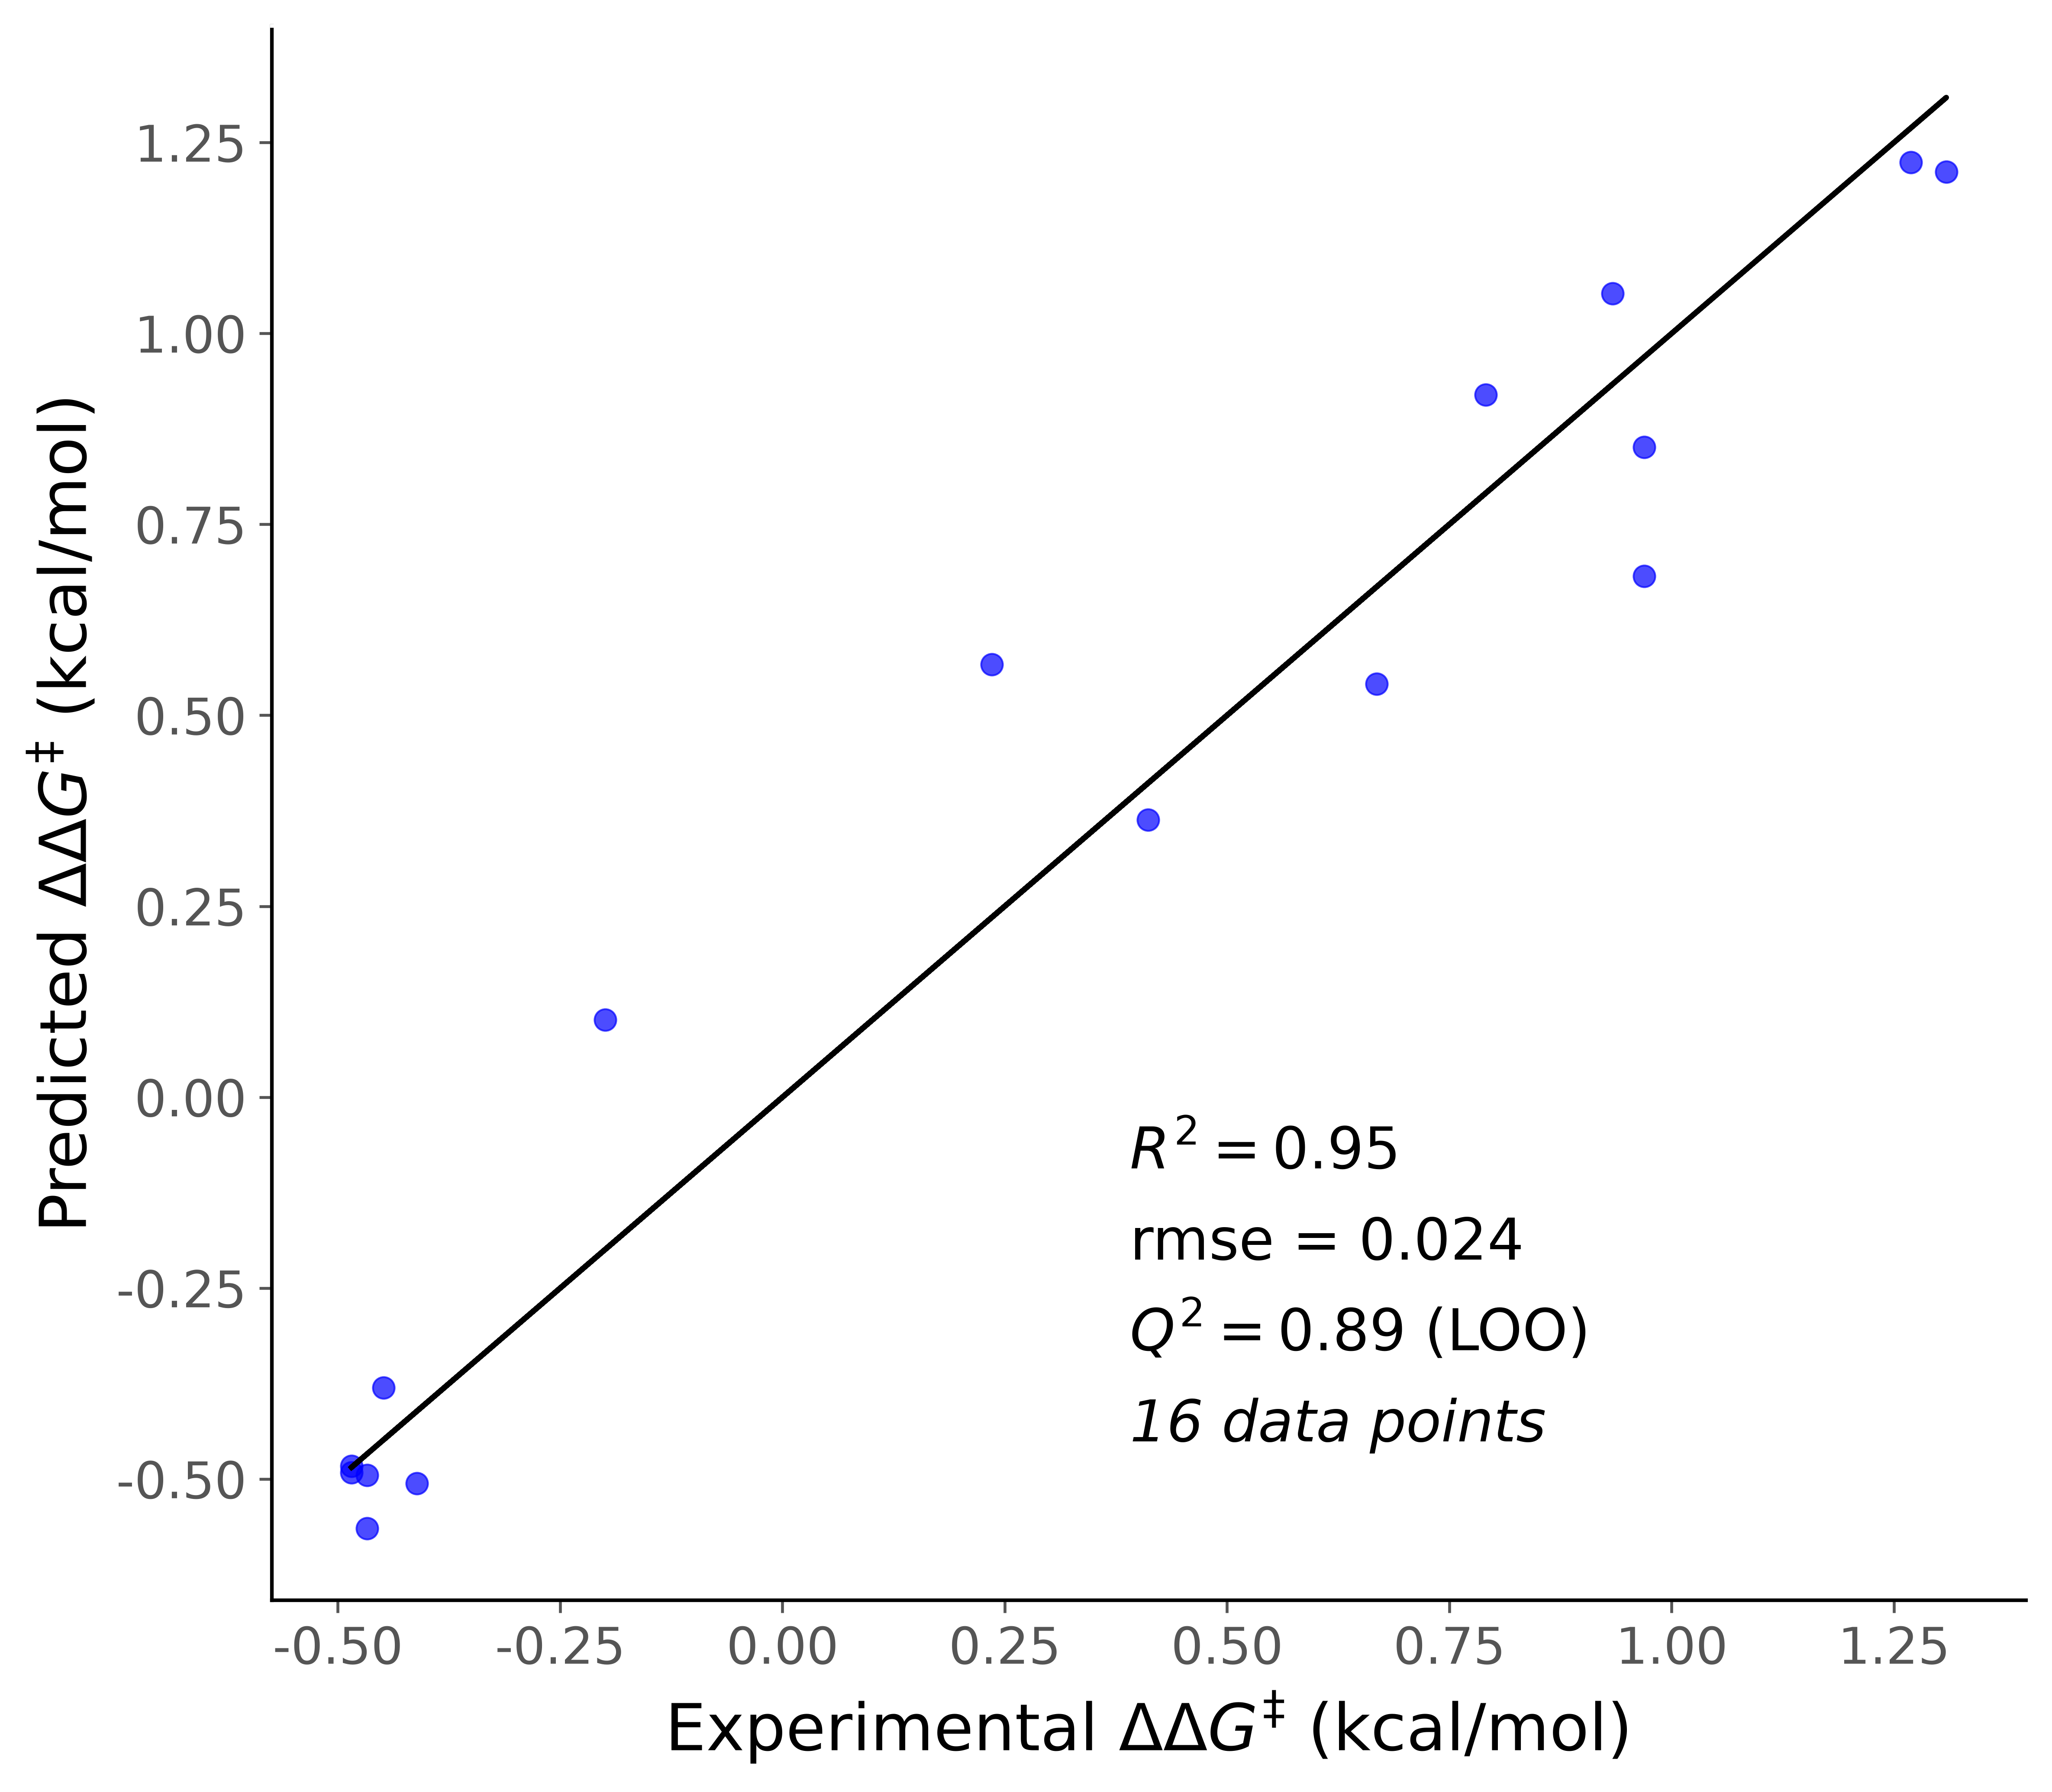

In [29]:
from matplotlib.ticker import FormatStrFormatter

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

fig.text(0.55, 0.35, '$R^2= 0.95$', fontsize = 16)
fig.text(0.55, 0.30, 'rmse = 0.024', fontsize = 16)
fig.text(0.55, 0.25, '$Q^2= 0.89$ (LOO)', fontsize = 16)
fig.text(0.55, 0.20, '16 data points', fontsize = 16, style = 'italic')
fig.tight_layout()

plt.savefig('LR_16.png', bbox_inches='tight')

In [30]:
from sklearn.ensemble import RandomForestRegressor
x2 = df[['%Vbur(3.0Å)','BL(C28-Pd)']]
y2 = df['ΔΔG_Exp']
regr = RandomForestRegressor(n_estimators=100, random_state=42)
regr.fit(x2,y2)
y_pred2 = regr.predict(x2)
r2 = regr.score(x2,y2)
print("rmse =", mean_squared_error(y2, y_pred2))
print("r2 =", regr.score(x2,y2))

rmse = 0.008546673767169763
r2 = 0.9814408418012368


In [31]:
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn import metrics

x3 = df[['%Vbur(3.0Å)','BL(C28-Pd)']]
y3 = df[['ΔΔG_Exp']]
x_array3 = np.array(x3)
y_array3 = np.array(y3)
loo = LeaveOneOut()
y_testall3 = []
y_predall3 = []
for train_i, test_i in loo.split(x3):
    x_train3, x_test3 = x_array3[train_i], x_array3[test_i]
    y_train3, y_test3 = y_array3[train_i], y_array3[test_i]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X = x_train3, y = y_train3)
    y_pred3 = model.predict(x_test3)
    
    y_testall3 += list(y_test3)
    y_predall3 += list(y_pred3)
    
rr = metrics.r2_score(y_testall3, y_predall3)
ms_error = metrics.mean_squared_error(y_testall3, y_predall3)

print("r2 =", rr, ",", "rmse =", ms_error)

/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/vishalrawat/NN/myenv/lib/python3.11/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was exp

r2 = 0.8486052377857128 , rmse = 0.06971876789055981


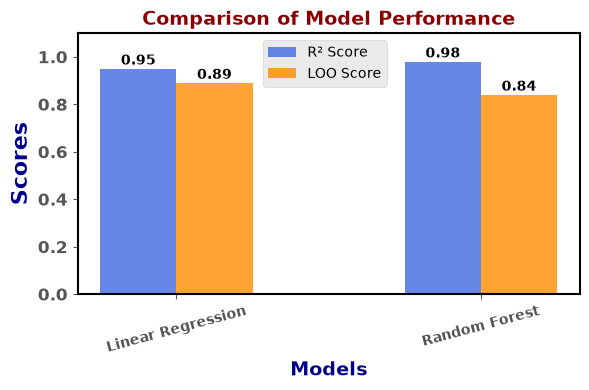

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
models = ['Linear Regression', 'Random Forest']
r2_scores = [0.95, 0.98]
loo_scores = [0.89, 0.84]

# Bar width and positions
x = np.arange(len(models))
width = 0.25

# Creating the bar chart with a white background
fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
ax.set_facecolor("white")  # Ensure the plot area is also white

bars1 = ax.bar(x - width/2, r2_scores, width, label='R² Score', color='royalblue', alpha=0.8)
bars2 = ax.bar(x + width/2, loo_scores, width, label='LOO Score', color='darkorange', alpha=0.8)

# Adding value labels on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', fontsize=10, fontweight="bold")

# Labels and title
ax.set_xlabel("Models", fontsize=14, fontweight="bold", color="darkblue")
ax.set_ylabel("Scores", fontsize=16, fontweight="bold", color="darkblue")  # Increased font size
ax.set_title("Comparison of Model Performance", fontsize=14, fontweight="bold", color="darkred")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)  # Improved readability

# Increase Y-axis limit
ax.set_ylim(0, 1.1)  # Adjust this to increase Y-axis space

# Ensure visible axes (spines)
for spine in ax.spines.values():
    spine.set_edgecolor("black")  # Set axis color
    spine.set_linewidth(1.5)  # Adjust thickness

# Adjust legend position
ax.legend(loc='upper right', bbox_to_anchor=(0.63, 1.0))

# Improve layout
plt.xticks(fontsize=10, fontweight="bold")
plt.yticks(fontsize=12, fontweight="bold")  # Increased Y-axis tick label size
plt.tight_layout()

# Save the plot with a white background and visible axes
plt.savefig("Linear_vs_Random_IPent.png", format="png", dpi=600, bbox_inches="tight", facecolor="white")

# Show plot
plt.show()

In [33]:
percent_vbur = -0.407786
BL = 2.156767

In [34]:
# Model equation parameters
coefficient_vbur = 0.697
coefficient_BL = -0.061
intercept = 0.287

In [35]:
Y_pred_V = coefficient_vbur * percent_vbur + coefficient_BL * BL + intercept

In [36]:
print(Y_pred_V)

-0.12878962899999996


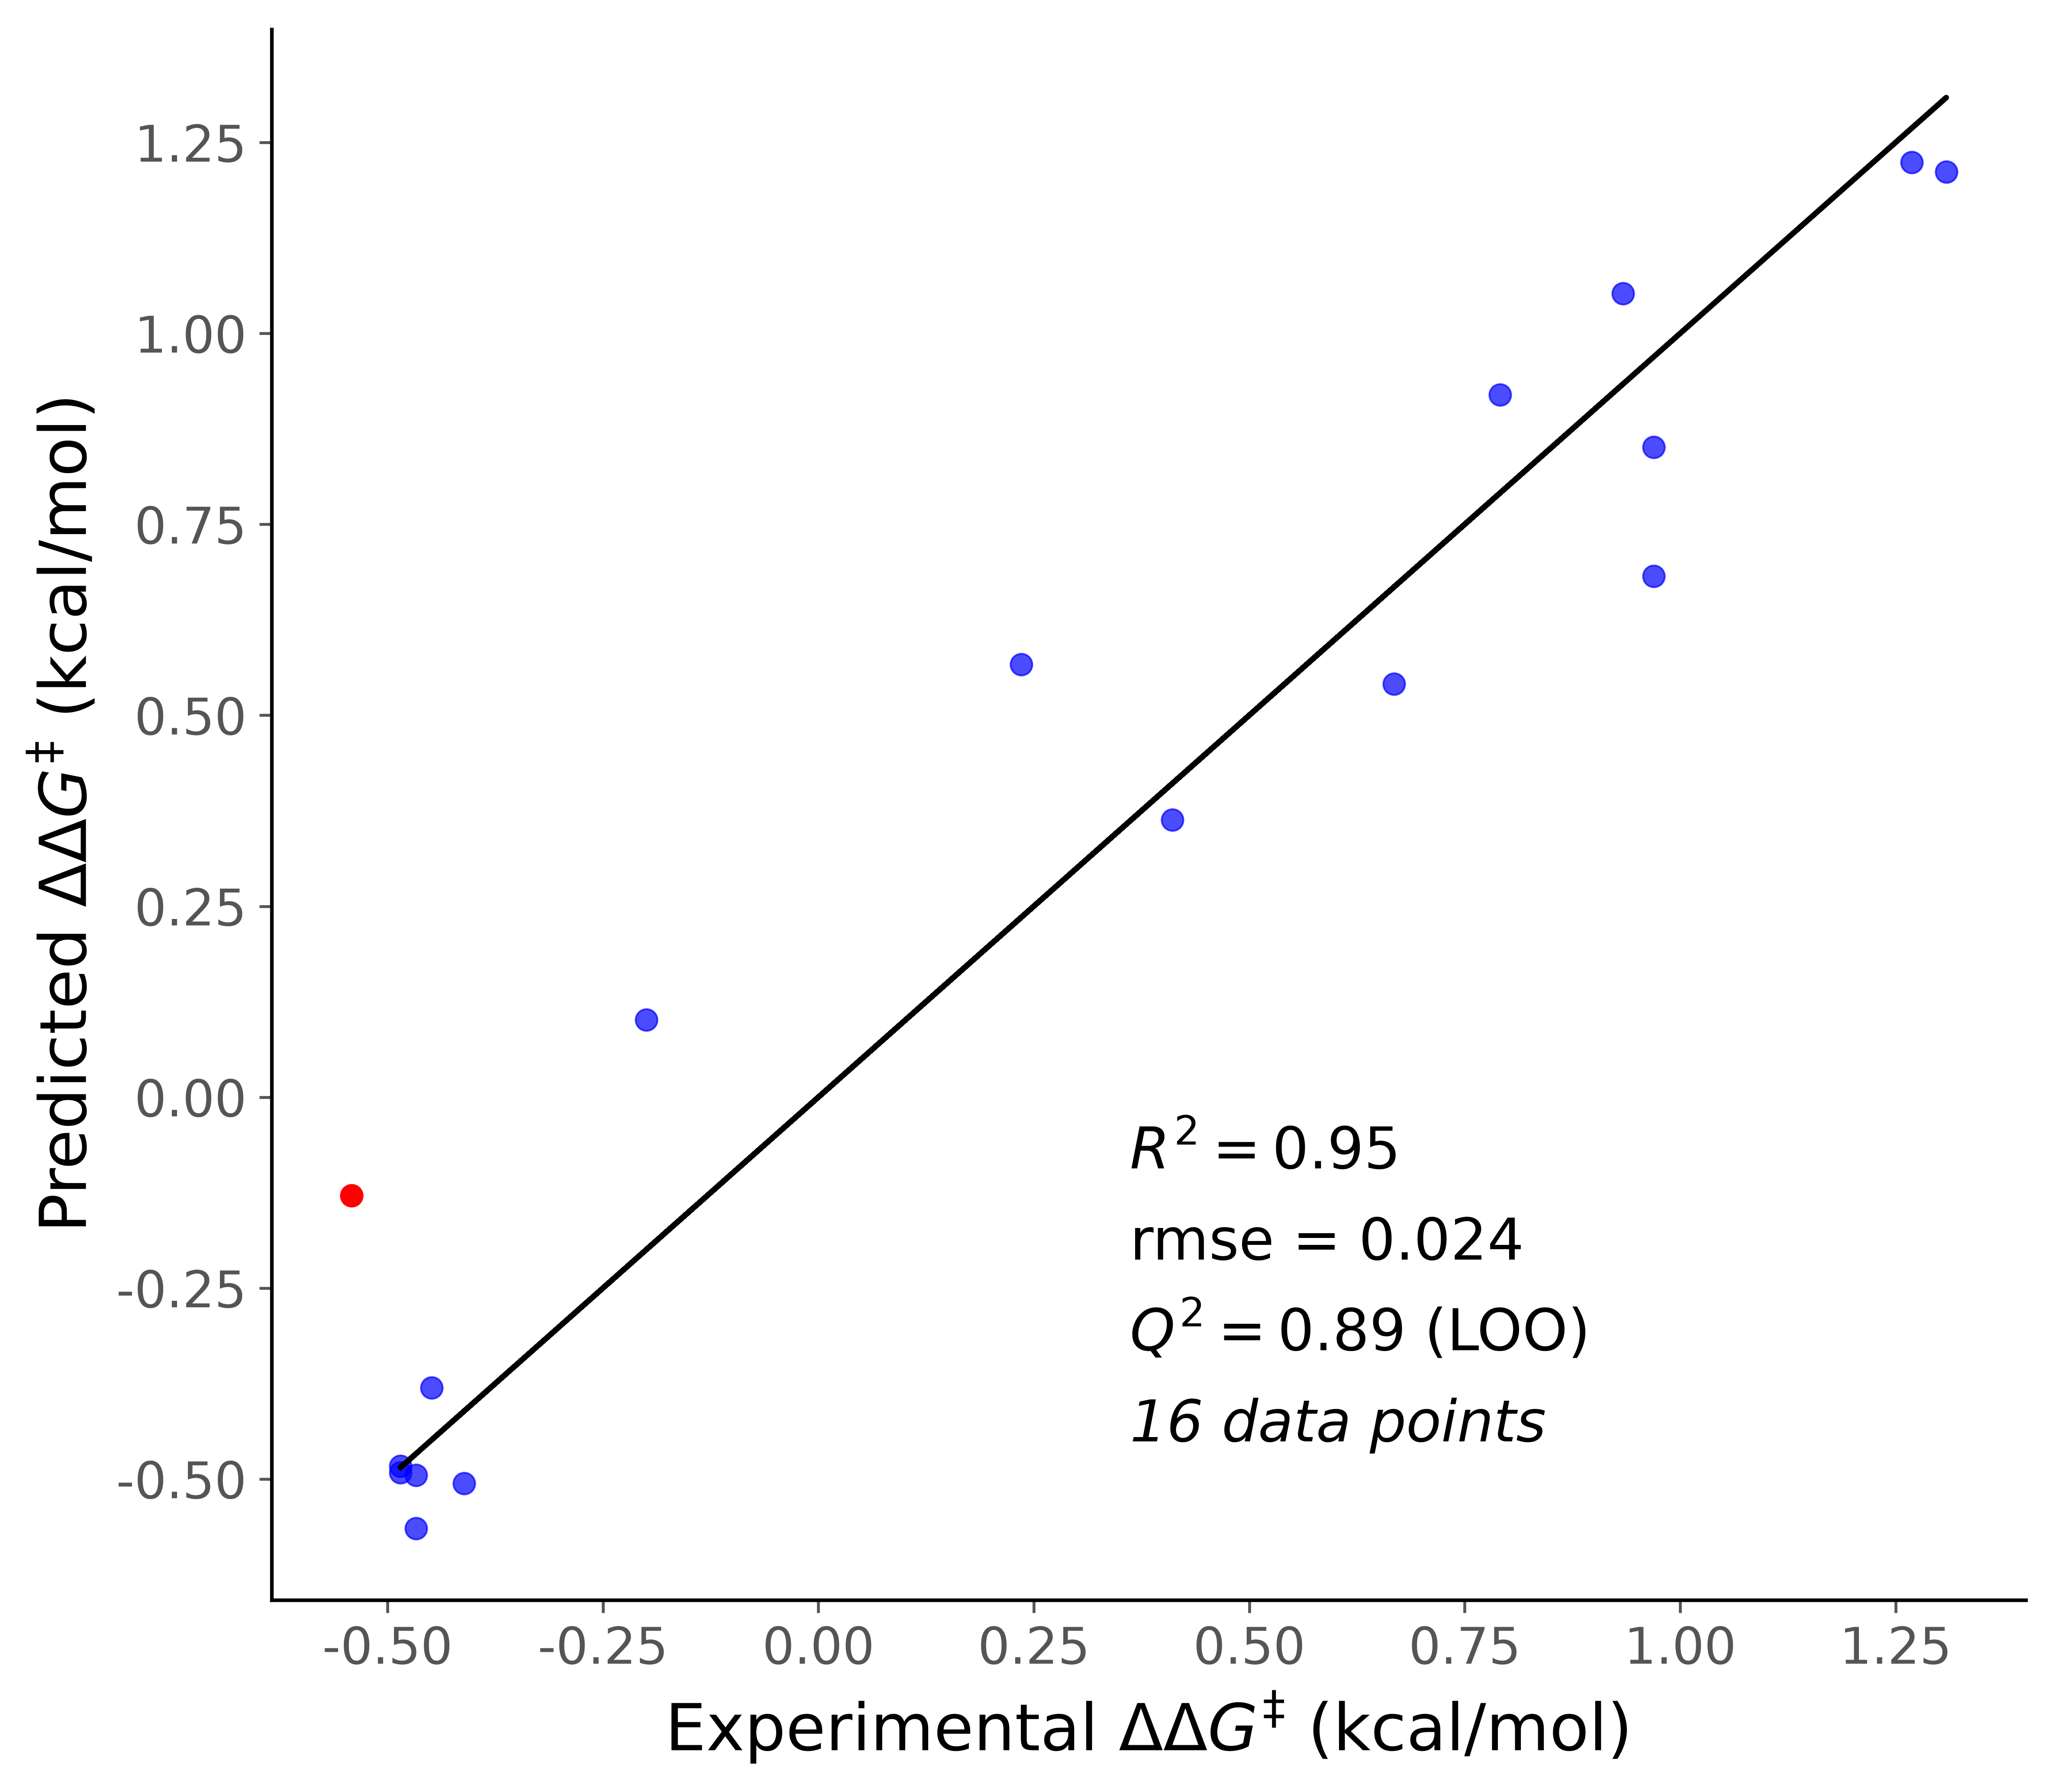

In [37]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

# Original plot and scatter
ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)

# New point: Y_actual = -0.541718, Y_Pred_V = 0.02086 (in red)
ax.scatter(-0.541718, -0.128790, edgecolor='r', facecolor='r', label='New Point')

# Axis labels and formatting
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

# Equation and statistics
fig.text(0.55, 0.35, '$R^2= 0.95$', fontsize=16)
fig.text(0.55, 0.30, 'rmse = 0.024', fontsize=16)
fig.text(0.55, 0.25, '$Q^2= 0.89$ (LOO)', fontsize=16)
fig.text(0.55, 0.20, '16 data points', fontsize=16, style='italic')

fig.tight_layout()

plt.savefig('LR_16_6SIMes.png', bbox_inches='tight')

In [38]:
percent_vbur_1 = 0.429136
BL_1 = 4.751749

In [39]:
# Model equation parameters
coefficient_vbur_1 = 0.697
coefficient_BL_1 = -0.061
intercept_1 = 0.287

In [40]:
Y_pred_V_1 = coefficient_vbur_1 * percent_vbur_1 + coefficient_BL_1 * BL_1 + intercept_1

In [41]:
print(Y_pred_V_1)

0.29625110299999996


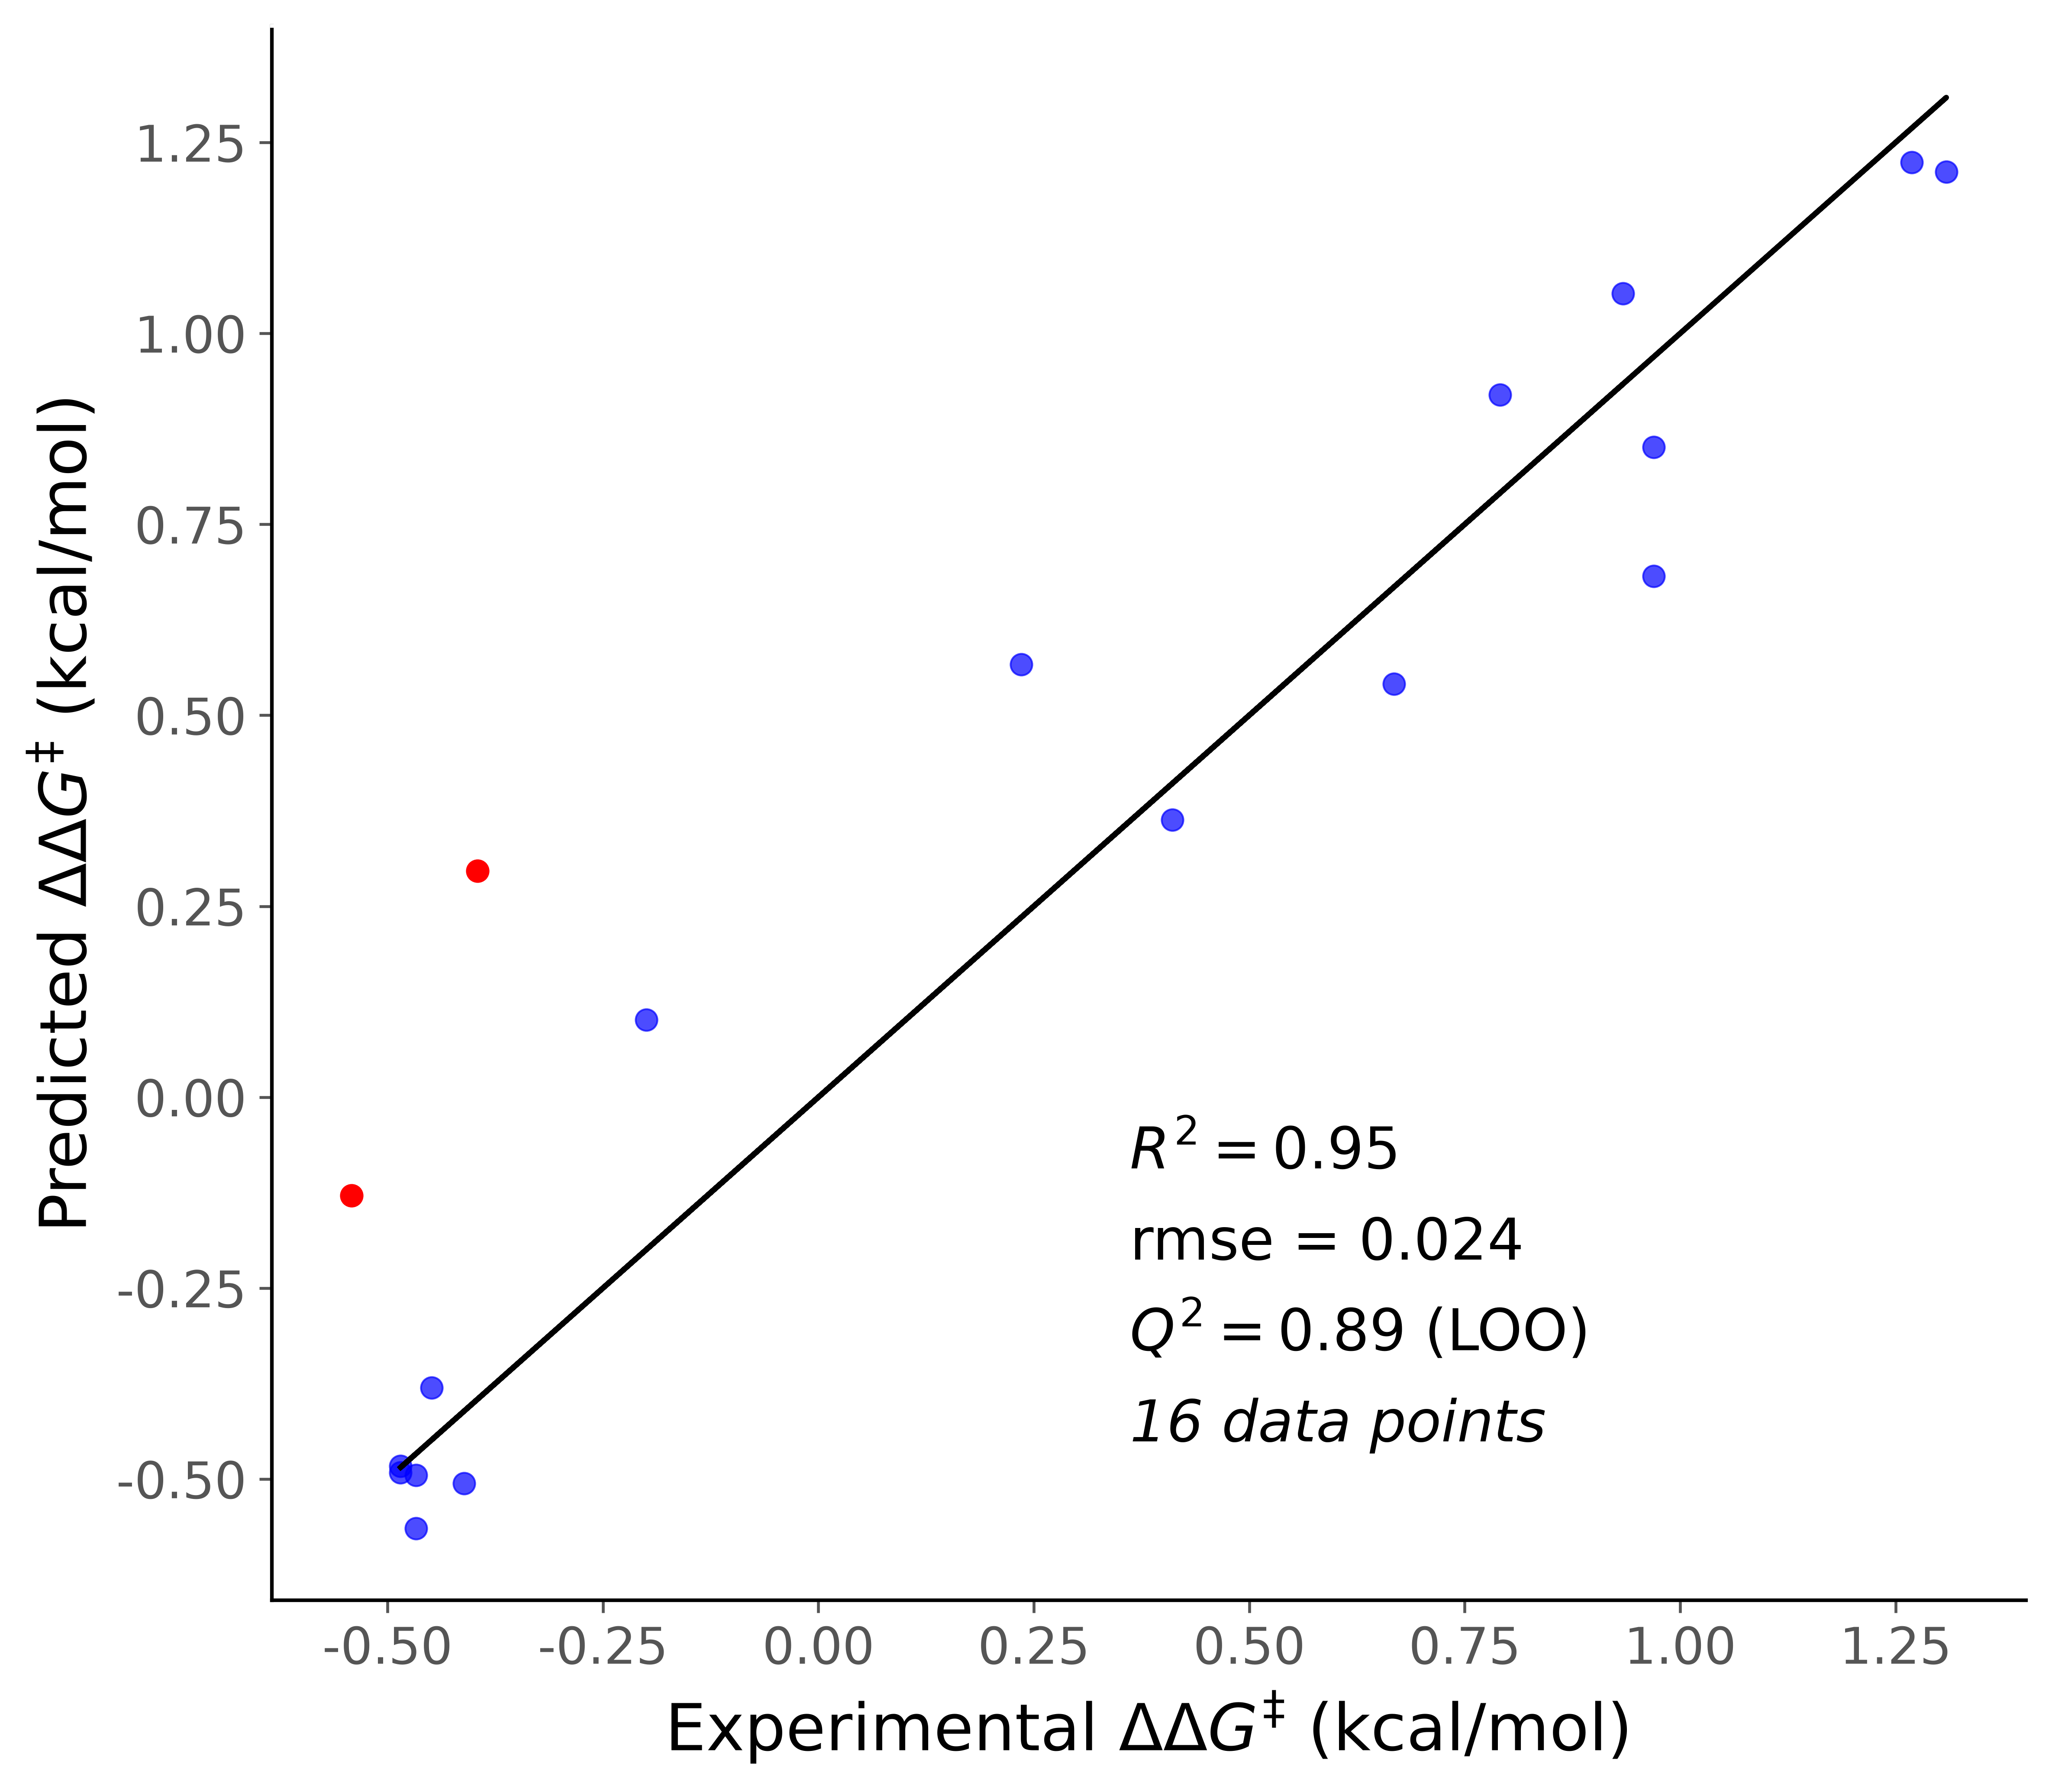

In [42]:
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt

plt.style.use('default')
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 7), dpi=600)

ax.set_facecolor('w')

# Original plot and scatter
ax.plot(y1, y1, color='k')
ax.scatter(y1, y_pred1, edgecolor='b', facecolor='b', alpha=0.7)

# New point: Y_actual = -0.541718, Y_Pred_V = 0.02086 (in red)
ax.scatter(-0.541718, -0.128790, edgecolor='r', facecolor='r', label='New Point')
ax.scatter(-0.395288, 0.296251, edgecolor='r', facecolor='r', label='New Point')

# Axis labels and formatting
ax.set_ylabel('Predicted $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.set_xlabel('Experimental $\Delta\Delta G^{‡}$ (kcal/mol)', fontsize=18, color='k')
ax.spines['bottom'].set_color('k')
ax.spines['left'].set_color('k')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=14)

# Equation and statistics
fig.text(0.55, 0.35, '$R^2= 0.95$', fontsize=16)
fig.text(0.55, 0.30, 'rmse = 0.024', fontsize=16)
fig.text(0.55, 0.25, '$Q^2= 0.89$ (LOO)', fontsize=16)
fig.text(0.55, 0.20, '16 data points', fontsize=16, style='italic')

fig.tight_layout()

plt.savefig('Figure 3B.png', bbox_inches='tight')